# Quality Control for Medical Image Segmentation with nnQC

Every segmentation pipeline eventually produces a bad mask. In a research
setting you notice because you look at the images; in a deployed setting nobody
looks, and there is no ground truth to compare against. **Segmentation quality
control** is the problem of estimating how good a mask is *without* ground
truth.

`nnQC` answers it with a generative model. It is a 2-D latent diffusion model
trained to reconstruct the *correct* segmentation from a *corrupted* one,
conditioned on the underlying scan:

```
scan + candidate mask  ──►  nnQC (latent diffusion)  ──►  reconstructed mask
                                                              │
                              agreement(candidate, reconstruction) = QC score
```

The intuition: the model has learned what plausible anatomy looks like for this
organ and modality. If your candidate mask agrees with what the model
reconstructs, it is probably fine. If they disagree, something is wrong with the
mask. Crucially, the QC score is computed **without ever seeing ground truth**,
so it works on new, unlabelled data.

This tutorial covers:

1. Running QC on a single scan + mask pair
2. Reading the per-slice breakdown to *localise* failures
3. Verifying calibration — does the score actually track true Dice?
4. Making the reconstruction more accurate (ensembling, post-processing)
5. Plugging in your own agreement metric

**Reference.** V. Marcianò et al., *Diffusion-Based Quality Control of Medical
Image Segmentations across Organs*, IEEE TMI 2026,
[doi:10.1109/TMI.2026.3714697](https://doi.org/10.1109/TMI.2026.3714697).

## Setup

nnQC builds on MONAI's `AutoencoderKL`, `DiffusionModelUNet` and
`DDIMScheduler`. Two notes on dependencies that are easy to get wrong:

- The scan encoder is **UniMedCLIP**, which needs the UniMed-CLIP *fork* of
  `open_clip` — upstream `open-clip-torch` lacks the `get_mean_std` and
  `text_encoder_name=` API that nnQC calls.
- The published UniMedCLIP checkpoint is a full *training* state, which
  PyTorch ≥ 2.6 will not open under its `weights_only=True` default.
  `scripts/prepare_backbone.py` fetches it and strips it to a plain
  `state_dict`.

In [1]:
# !pip install -q "monai>=1.4" nibabel scipy scikit-image matplotlib opencv-python-headless lpips
# !pip install -q git+https://github.com/mbzuai-oryx/UniMed-CLIP.git
# !pip install -q -e .
# !python scripts/prepare_backbone.py     # once: UniMedCLIP + BiomedBERT + LPIPS

import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

# A notebook runs from its own directory, so put the repo root on sys.path to
# make `from scripts.benchmark import ...` work regardless of where it is run.
ROOT = os.environ.get("NNQC_ROOT", os.path.abspath(".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import nnqc
from nnqc.config import resolve_config

print("nnqc", nnqc.__version__)
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())

nnqc 0.1.0
torch 2.9.1+cu128 | cuda True


## Choose a task

A task is an `(env.json, config.json)` pair: the env file points at the data and
the checkpoints, the config file carries the network and training
hyper-parameters. The tutorial defaults to the cardiac model (ACDC: right
ventricle, myocardium, left ventricle) but every cell below works unchanged for
`prostate` (MSD: peripheral + transition zone) or `liver` (MSD: whole liver organ,
binary — labels 1 and 2 merged, so lesions count as liver).

In [2]:
TASK = os.environ.get("NNQC_TASK", "cardiac")   # ROOT was set in the setup cell

CFG = f"{ROOT}/configs/jz/{TASK}/config.json"
ENV = f"{ROOT}/configs/jz/{TASK}/env.json"

cfg = resolve_config(CFG, ENV, None, stage="diffusion")
CLASS_NAMES = {
    "cardiac":  ["background", "right ventricle", "myocardium", "left ventricle"],
    "prostate": ["background", "peripheral zone", "transition zone"],
    "liver":    ["background", "liver"],          # binary: num_classes=1
}[TASK]

print(f"task           : {TASK}")
print(f"modality       : {cfg.modality}")
print(f"classes        : {CLASS_NAMES}")
print(f"checkpoints    : {cfg.model_dir}")
print(f"latent channels: {cfg.latent_channels}  |  UNet in_channels: {cfg.diffusion_def['in_channels']}")

task           : prostate
modality       : mri
classes        : ['background', 'peripheral zone', 'transition zone']
checkpoints    : /lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/runs/prostate/weights
latent channels: 2  |  UNet in_channels: 3


### A note on `scale_factor`

The autoencoder's latents are rescaled before the diffusion model sees them, by
a factor derived from the data. That factor is **part of the trained model** —
if inference re-estimates it from whatever happens to be at hand, sampling runs
at a different scale than training did and reconstructions degrade.

nnQC writes it to `scale_factor.txt` at training time and reads it back at
inference. If you are working with an older checkpoint that predates this file,
you will get a warning and a fallback estimate.

In [3]:
scale_path = os.path.join(cfg.model_dir, "scale_factor.txt")
print(f"{scale_path}: {open(scale_path).read().strip() if os.path.exists(scale_path) else 'MISSING (will estimate)'}")

/lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/runs/prostate/weights/scale_factor.txt: 0.86509222


## 1. Quality control on one mask

`nnqc.check()` is the whole API for inference. It takes a scan and a candidate
segmentation, applies the same preprocessing used in training (orientation,
foreground crop, resize, intensity scaling), samples a reconstruction, and
returns the agreement.

To show the score responds to quality, we run it twice: once on a
ground-truth mask, once on a deliberately degraded version of the same mask.

In [4]:
from pathlib import Path
from scripts.benchmark import corrupt_volume, val_volumes   # helpers shipped with the repo
import nibabel as nib

pairs = val_volumes(cfg)          # held-out volumes, same split as training
sample = pairs[0]
print("scan:", Path(sample["image"]).name)
print("mask:", Path(sample["label"]).name)

# Build a degraded copy of the ground-truth mask to act as a "bad" candidate.
gt_img = nib.load(sample["label"])
gt_arr = np.asanyarray(gt_img.dataobj)
work = Path("qc_demo"); work.mkdir(exist_ok=True)

t = torch.from_numpy(gt_arr.astype(np.float32)).permute(2, 0, 1).unsqueeze(1)
bad = corrupt_volume(t, cfg.num_classes, severity=1.0, seed=0)
bad_arr = bad[:, 0].permute(1, 2, 0).numpy()
bad_path = work / "candidate_bad.nii.gz"
nib.save(nib.Nifti1Image(bad_arr.astype(np.float32), gt_img.affine), bad_path)
print("wrote", bad_path)

/lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/venv/lib64/python3.11/site-packages/huggingface_hub/constants.py:298: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


Scanning 56 files...
Found 28 images and 28 labels.
Successfully created 28 pairs.
scan: prostate_35_img.nii.gz
mask: prostate_35_gt.nii.gz


wrote qc_demo/candidate_bad.nii.gz


In [5]:
good = nnqc.check(sample["image"], sample["label"], config=CFG, env=ENV, num_steps=5)
bad_result = nnqc.check(sample["image"], str(bad_path), config=CFG, env=ENV, num_steps=5)

print(f"\nQC score, ground-truth mask : {good.qc_score:.3f}")
print(f"QC score, corrupted mask   : {bad_result.qc_score:.3f}")
# Binary tasks report no per-class breakdown - there is only one foreground class.
if good.qc_score_per_class:
    print(f"\nper-class (GT)  : { {CLASS_NAMES[k]: round(v,3) for k,v in good.qc_score_per_class.items()} }")
    print(f"per-class (bad) : { {CLASS_NAMES[k]: round(v,3) for k,v in bad_result.qc_score_per_class.items()} }")
else:
    print(f"\n(binary task: {CLASS_NAMES[1]} only, no per-class breakdown)")

/lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/venv/lib64/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[nnqc] check | device=cuda num_classes=3 steps=5


/lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/venv/lib64/python3.11/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 43145.42it/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 45181.42it/s]


[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

[nnqc] scale_factor = 0.8651 (from /lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/runs/prostate/weights/scale_factor.txt)


[nnqc] QC score (dice, higher=better) = 0.6716

QC score, ground-truth mask : 0.893
QC score, corrupted mask   : 0.672

per-class (GT)  : {'peripheral zone': 0.426, 'transition zone': 0.848}
per-class (bad) : {'peripheral zone': 0.304, 'transition zone': 0.677}


The corrupted mask should score markedly lower. That gap *is* the QC signal —
and note that producing it required no ground truth: `check()` only ever saw the
scan and the candidate.

`QCResult` also reports `metric_name` and `higher_is_better`, so downstream code
can interpret the number without assuming Dice.

## 2. Localising the failure

A volume-level score tells you *that* a mask is suspect. `slice_scores` tells
you **where**, which is what a human reviewer actually needs. Plotting agreement
against normalised slice position (0 = apex, 1 = base) turns QC into a triage
tool: the dips are the slices to open first.

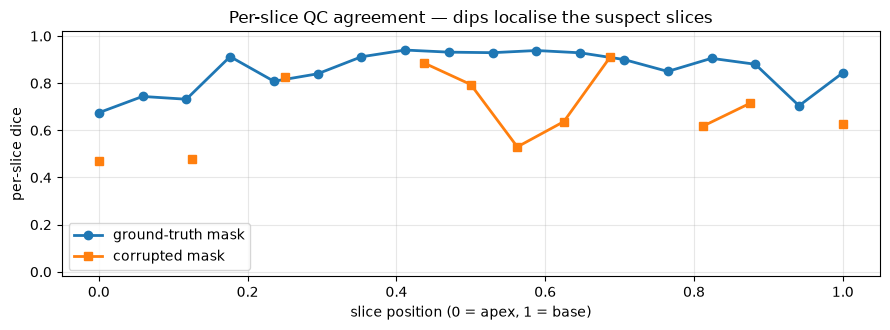

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(good.slice_ratios, good.slice_scores, "o-", label="ground-truth mask", lw=2)
ax.plot(bad_result.slice_ratios, bad_result.slice_scores, "s-", label="corrupted mask", lw=2)
ax.set_xlabel("slice position (0 = apex, 1 = base)")
ax.set_ylabel(f"per-slice {good.metric_name}")
ax.set_title("Per-slice QC agreement — dips localise the suspect slices")
ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 3. Is the score actually calibrated?

This is the question that decides whether a QC model is useful. A score that
reconstructs beautifully but ranks bad masks above good ones is worthless for
triage.

So we sweep a range of corruption severities, and for each candidate compare:

- what nnQC reports — `Dice(candidate, reconstruction)`, computed blind, and
- the truth — `Dice(candidate, ground truth)`.

A well-calibrated QC model puts these on the diagonal. What matters most is
**rank** correlation (Spearman): can it order masks from worst to best?

In [7]:
from scripts.benchmark import multiclass_dice

qc_scores, true_dices = [], []
for vol in pairs[:6]:
    img_nii = nib.load(vol["label"])

    for sev in [0.0, 0.25, 0.5, 0.75, 1.0]:
        if sev == 0.0:
            cand_path = vol["label"]                      # severity 0 = the GT itself
            cand_raw = np.asanyarray(img_nii.dataobj)
        else:
            raw = torch.from_numpy(np.asanyarray(img_nii.dataobj).astype(np.float32))
            raw = raw.permute(2, 0, 1).unsqueeze(1)
            c = corrupt_volume(raw, cfg.num_classes, severity=sev, seed=hash(vol["image"]) % 1000)
            cand_raw = c[:, 0].permute(1, 2, 0).numpy()
            cand_path = str(work / "tmp_cand.nii.gz")
            nib.save(nib.Nifti1Image(cand_raw.astype(np.float32), img_nii.affine), cand_path)

        # What nnQC reports, with no access to ground truth.
        res = nnqc.check(vol["image"], cand_path, config=CFG, env=ENV,
                         num_steps=5, return_volume=False)

        # The truth, measured on the ORIGINAL grid.
        #
        # Not on the preprocessed grid: `check()` crops to the *candidate's* own
        # nonzero slice extent, so a candidate that loses foreground on an end
        # slice crops one slice shorter than the ground truth does. Preprocessing
        # the two independently then yields mismatched shapes
        # (256,256,8) vs (256,256,9). Both are defined on the original grid, so
        # that is where they can be compared.
        raw_gt = np.asanyarray(img_nii.dataobj)
        true_dices.append(multiclass_dice(cand_raw, raw_gt, cfg.num_classes))
        qc_scores.append(res.qc_score)

qc_scores, true_dices = np.array(qc_scores), np.array(true_dices)
print(f"collected {len(qc_scores)} (candidate, score) pairs")

[nnqc] check | device=cuda num_classes=3 steps=5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 38223.52it/s]


[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

[nnqc] scale_factor = 0.8651 (from /lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/runs/prostate/weights/scale_factor.txt)


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 40870.45it/s]


[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

[nnqc] scale_factor = 0.8651 (from /lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/runs/prostate/weights/scale_factor.txt)


[nnqc] QC score (dice, higher=better) = 0.6825
collected 25 (candidate, score) pairs


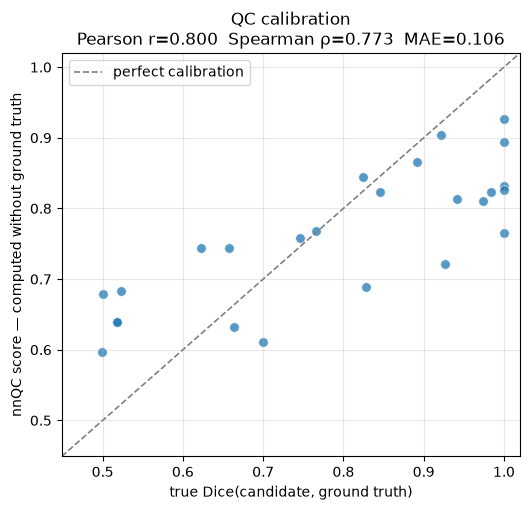

Pearson  r = 0.8002  (p=1.57e-06)
Spearman ρ = 0.7729  (p=5.94e-06)  <- rank agreement, the triage-relevant one
MAE        = 0.1065  (QC score as a direct estimate of Dice)


In [8]:
from scipy.stats import spearmanr, pearsonr

pear = pearsonr(qc_scores, true_dices)
spear = spearmanr(qc_scores, true_dices)
mae = np.mean(np.abs(qc_scores - true_dices))

fig, ax = plt.subplots(figsize=(5.4, 5.2))
ax.scatter(true_dices, qc_scores, s=48, alpha=0.75, edgecolor="white", linewidth=0.6)
lims = [min(true_dices.min(), qc_scores.min()) - 0.05, 1.02]
ax.plot(lims, lims, "--", color="0.5", lw=1.2, label="perfect calibration")
ax.set_xlabel("true Dice(candidate, ground truth)")
ax.set_ylabel("nnQC score — computed without ground truth")
ax.set_title(f"QC calibration\nPearson r={pear[0]:.3f}  Spearman ρ={spear.statistic:.3f}  MAE={mae:.3f}")
ax.set_xlim(lims); ax.set_ylim(lims); ax.grid(alpha=0.3); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

print(f"Pearson  r = {pear[0]:.4f}  (p={pear[1]:.2e})")
print(f"Spearman ρ = {spear.statistic:.4f}  (p={spear.pvalue:.2e})  <- rank agreement, the triage-relevant one")
print(f"MAE        = {mae:.4f}  (QC score as a direct estimate of Dice)")

## 4. Making the reconstruction more accurate

The QC score is only as good as the reconstruction it compares against. Three
inference-time upgrades in `nnqc.refine` improve that reconstruction — neither
requires retraining:

| technique | knob | idea | cost |
|---|---|---|---|
| **Ensembling** | `num_samples` | average the decoded probabilities over N noise draws; variance falls ~1/√N | ×N sampling |
| **Post-processing** | `postprocess` | fill enclosed holes in the reconstruction. Deliberately *not* connected-component filtering — see the warning below | negligible |

### Two post-processing traps, both measured rather than assumed

**Connected-component filtering amputates apex and base.** "Keep only the largest
3-D component" is the obvious way to remove isolated off-organ blobs, and it is
what an earlier version of this preset did. Measured on prostate over 25 paired
volume/severity pairs it cost **apex −0.10 and base −0.16 Dice** (worse in 19/25
each) and erased the base structure outright in 8/25 cases. The reason is
structural: at the extremes the cross-section is genuinely small — 16 voxels
against a 432-voxel body in the regression fixture, under 4% — and one missed
slice disconnects it in 3-D. So *any* keep-the-big-ones rule either spares the
specks it exists to remove or deletes real anatomy. It is off by default;
`largest_component` / `min_component_frac` remain available for compact,
untapered organs where you have measured that they help.

**Hole-filling must never overwrite a nested class.** Myocardium is a ring with
the blood pool inside it, so filling holes in the myocardium without a
background-only guard relabels the entire left ventricle. Guarded, and pinned by
`tests/test_refine.py`.

What remains on by default is hole-filling alone, because it is *monotone*: it
can add voxels inside a structure but never delete one.

Gaussian smoothing along z (`z_sigma`) is also available and also off — its
benefit is task-dependent and it can outvote structures thinner than the kernel.

In [9]:
from nnqc.refine import PRESETS

for name, spec in PRESETS.items():
    pp = spec["postprocess"]
    print(f"{name:<11} steps={spec['num_steps']:<3} samples={spec['num_samples']} "
          f"cc={pp.largest_component} "
          f"holes={pp.fill_holes} z_sigma={pp.z_sigma}")

baseline    steps=5   samples=1 cc=False holes=False z_sigma=0.0
cleanup     steps=5   samples=1 cc=False holes=True z_sigma=0.0
ensemble    steps=5   samples=5 cc=False holes=True z_sigma=0.0
long_chain  steps=25  samples=3 cc=False holes=True z_sigma=0.0
z_smooth    steps=5   samples=5 cc=False holes=True z_sigma=0.5


`scripts/benchmark.py` measures every preset on held-out data. It reports both
things that matter: how good the *reconstruction* is (`recon_dice`, against
ground truth) and how well the *score* tracks true quality (correlation, MAE).

```bash
python scripts/benchmark.py --task cardiac \
    --presets baseline cleanup ensemble \
    --num-volumes 20 --out results/cardiac.json
```

In [10]:
import subprocess, sys, json as _json

# Absolute paths and an explicit cwd: a notebook is executed from its own
# directory (tutorials/), so repo-relative paths resolve to tutorials/scripts/...
out_json = f"{ROOT}/results/{TASK}_notebook.json"
subprocess.run([sys.executable, f"{ROOT}/scripts/benchmark.py", "--task", TASK,
                "--presets", "baseline", "cleanup", "ensemble",
                "--num-volumes", "6", "--severities", "0.0", "0.5", "1.0",
                "--out", out_json], check=True, cwd=ROOT)

summary = _json.load(open(out_json))["summary"]
print(f"\n{'preset':<11}{'recon Dice':>12}{'Spearman':>11}{'MAE':>9}{'s/vol':>8}")
for name, s in summary.items():
    print(f"{name:<11}{s['recon_dice']:>12.4f}{s['spearman']:>11.4f}{s['mae']:>9.4f}{s['seconds']:>8.1f}")

/lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/venv/lib64/python3.11/site-packages/huggingface_hub/constants.py:298: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


/lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/venv/lib64/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 41841.09it/s]
[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be

[nnqc] scale_factor = 0.8651 (from /lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/runs/prostate/weights/scale_factor.txt)
Scanning 56 files...
Found 28 images and 28 labels.
Successfully created 28 pairs.
[bench] task=prostate volumes=5 presets=['baseline', 'cleanup', 'ensemble'] severities=[0.0, 0.5, 1.0] num_classes=3


/lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/venv/lib64/python3.11/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


...

  vol04 sev=0.5 ensemble    true=0.816 recon=0.785 qc=0.752  [apex 0.482 mid 0.859 base 0.662] (1.1s)


  vol04 sev=1.0 baseline    true=0.519 recon=0.605 qc=0.569  [apex 0.288 mid 0.775 base 0.500] (0.3s)


  vol04 sev=1.0 cleanup     true=0.519 recon=0.605 qc=0.569  [apex 0.288 mid 0.775 base 0.500] (0.3s)


  vol04 sev=1.0 ensemble    true=0.519 recon=0.632 qc=0.590  [apex 0.267 mid 0.782 base 0.515] (1.0s)

preset        recon_dice    apex     mid    base  qc-vs-true r  spearman  |qc-true|   s/vol
----------------------------------------------------------------------------------------------------
baseline       0.5571±0.173   0.414   0.607   0.471        0.2168    0.4328     0.2491     0.5
cleanup        0.5571±0.173   0.414   0.607   0.471        0.2168    0.4328     0.2491     0.4
ensemble       0.5701±0.177   0.398   0.619   0.480        0.1883    0.4183     0.2442     1.5
recon_dice   = Dice(reconstruction, GT)      - higher is a better reconstruction
apex/mid/base= the same, split into thirds along the slice axis. A healthy
               volume Dice can still hide collapsed extremes; apex << mid means
               the model is emitting average-sized structures at the ends.
qc-vs-true r = corr(QC score, true Dice)     - higher means better-calibrated QC
|qc-true|    = mean abs err


preset       recon Dice   Spearman      MAE   s/vol
baseline         0.5571     0.4328   0.2491     0.5
cleanup          0.5571     0.4328   0.2491     0.4
ensemble         0.5701     0.4183   0.2442     1.5


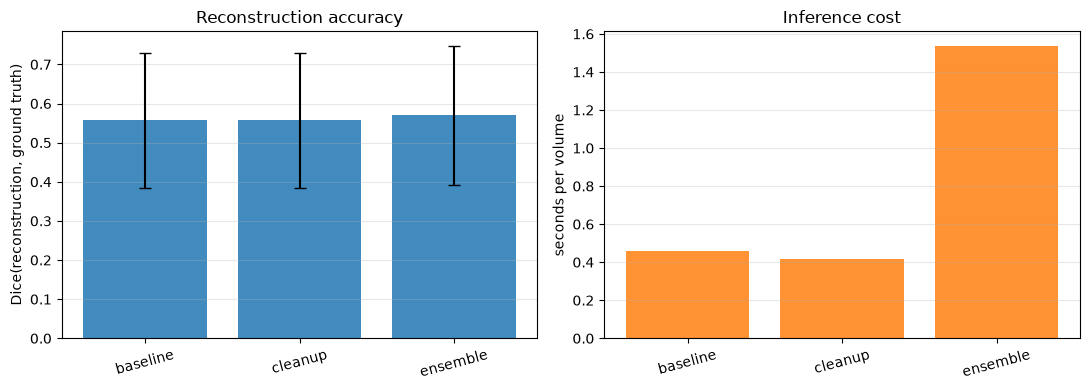

In [11]:
names = list(summary)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(names, [summary[n]["recon_dice"] for n in names],
            yerr=[summary[n]["recon_dice_std"] for n in names], capsize=4, alpha=0.85)
axes[0].set_ylabel("Dice(reconstruction, ground truth)")
axes[0].set_title("Reconstruction accuracy")
axes[1].bar(names, [summary[n]["seconds"] for n in names], alpha=0.85, color="tab:orange")
axes[1].set_ylabel("seconds per volume")
axes[1].set_title("Inference cost")
for ax in axes:
    ax.grid(alpha=0.3, axis="y"); ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

## 5. Custom agreement metrics

Dice is the default, but "agreement" is a modelling choice. Pass `metric=` a
built-in name, any callable `fn(pred, ref) -> float`, or a `Metric` subclass.
`QCResult` carries `metric_name` and `higher_is_better` so the orientation of
the score is never ambiguous — important for distance metrics, where *lower* is
better.

In [12]:
from nnqc.metrics import Metric

class BoundaryAgreement(Metric):
    # Fraction of candidate boundary voxels lying on/near the reconstruction.
    name = "boundary_agreement"
    higher_is_better = True

    def score(self, pred, ref):
        from scipy.ndimage import binary_erosion
        pb = ref & ~binary_erosion(ref)
        if pb.sum() == 0:
            return float("nan")
        from scipy.ndimage import binary_dilation
        near = binary_dilation(pred, iterations=2)
        return float((pb & near).sum() / pb.sum())

for metric in ["dice", "iou", BoundaryAgreement()]:
    r = nnqc.check(sample["image"], str(bad_path), config=CFG, env=ENV,
                   metric=metric, num_steps=5, return_volume=False)
    arrow = "higher=better" if r.higher_is_better else "lower=better"
    print(f"{r.metric_name:<20} {r.qc_score:.4f}   ({arrow})")

[nnqc] check | device=cuda num_classes=3 steps=5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 37211.34it/s]


[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

[nnqc] scale_factor = 0.8651 (from /lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/runs/prostate/weights/scale_factor.txt)


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 38905.64it/s]


[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

[nnqc] scale_factor = 0.8651 (from /lustre/fsn1/projects/rech/rpv/uxl51vf/nnqc/runs/prostate/weights/scale_factor.txt)


[nnqc] QC score (boundary_agreement, higher=better) = 0.9463
boundary_agreement   0.9463   (higher=better)


## 6. Using nnQC on your own data

Two paths:

**Run an existing model on new scans.** If your organ and modality match a
trained task, `check()` works directly — nothing to configure.

**Train on a new organ.** Copy `configs/jz/<task>/` and edit:

- `env.json` — `data_base_dir` + `task` (data lives at `<data_base_dir>/<task>/`),
  `image_pattern` / `label_pattern`, `num_classes` (**including background**),
  `modality` (`mri` / `ct` / `us`, which selects intensity normalisation)
- `config.json` — keep `diffusion_def.in_channels == latent_channels + 1`; the
  extra channel carries the candidate mask

Name files so image and label identifiers match exactly (`case01_img.nii.gz` /
`case01_gt.nii.gz`). nnQC pairs by fuzzy identifier score and drops anything
below an exact match, warning about what it skipped — an unpaired file is much
better than a silently mismatched one.

```bash
nnqc train-autoencoder --config my/config.json --env my/env.json --epochs 500
nnqc train-diffusion   --config my/config.json --env my/env.json --epochs 4000
```

On multiple GPUs, use `torchrun` — the loaders shard by volume across ranks:

```bash
torchrun --standalone --nnodes=1 --nproc_per_node=4 \
    -m nnqc.cli train-diffusion --config my/config.json --env my/env.json -g 4
```

## Summary

- nnQC estimates segmentation quality with **no ground truth**, by reconstructing
  the mask it believes is correct and measuring agreement.
- The per-slice breakdown localises failures, making it usable for triage rather
  than just scoring.
- Calibration — how well the score ranks true quality — is the metric that
  decides usefulness, and is what `scripts/benchmark.py` reports.
- Reconstruction accuracy can be improved at inference time via ensembling and
  post-processing, with no retraining — but *measure* it per task. On prostate,
  connected-component cleanup made apex and base markedly worse while looking
  like an obvious win, which is why `scripts/benchmark.py` reports Dice split
  into apex/mid/base thirds rather than a single volume number.